# Investigations of datasets from arxiv and huggingface
With the purpose of comparing trends in the two sources, at the same time period, the goal here is to find a common time period with plenty of data in both datasets.
We then want to create subsets of the datasets, with time stamps uniformly distributed.

In [1]:
import dataset_loader
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
arx = dataset_loader._load_arxiv_timeline()
hf = dataset_loader._load_hf_timeline()

# lets investigate hf dataset first
ensure there is enough info to be able to infer acm class

In [18]:
df = hf.select(["modelId", "createdAt", "last_modified", "card", "tags", "pipeline_tag"]).to_pandas()

AttributeError: 'DataFrame' object has no attribute 'select'

In [20]:
hf["createdAt"].min()

Timestamp('2022-03-02 23:29:04')

In [21]:
hf

,modelId,createdAt,last_modified,card,tags,pipeline_tag
5,sasawq21/test-20250923-025008,2025-09-23 02:50:12,2025-09-25 03:29:41,---\nbase_model: google/medgemma-4b-it\nlibrar...,"[transformers, safetensors, generated_from_tra...",None
6,noobmaster6009/Qwen2.5-0.5B-Instruct-Gensyn-Sw...,2025-09-14 15:07:37,2025-09-25 02:50:55,---\nlibrary_name: transformers\ntags:\n- rl-s...,"[transformers, safetensors, qwen2, text-genera...",text-generation
8,valiantcat/DeepSeek-R1-Distill-Qwen-Fortune-14B,2025-09-25 01:45:18,2025-09-25 01:54:26,---\nlibrary_name: transformers\ntags:\n- unsl...,"[transformers, safetensors, qwen2, text-genera...",text-generation
9,kibaraki/wav2vec2-large-xlsr-53-shinekhen-buryat,2025-09-16 20:45:31,2025-09-25 01:46:27,---\nlicense: cc-by-sa-4.0\nbase_model:\n- fac...,"[safetensors, wav2vec2, automatic-speech-recog...",automatic-speech-recognition
10,Linksome/QwQ-32B-10000r_1_Base_3eps,2025-09-25 01:34:34,2025-09-25 01:45:53,---\nlibrary_name: transformers\nlicense: othe...,"[transformers, safetensors, qwen2, text-genera...",text-generation
...,...,...,...,...,...,...
974904,Muapi/starwars-characters,2025-08-22 23:10:41,2025-08-22 23:10:49,---\nlicense: openrail++\ntags:\n - lora\n -...,"[lora, stable-diffusion, flux.1-d, license:ope...",None
974906,akashmaggon/LLAMA-8.5B-GRPO-RedditModerator,2025-08-22 20:30:13,2025-08-22 21:21:46,---\nbase_model: meta-llama/Llama-3.1-8B-Instr...,"[transformers, tensorboard, safetensors, gener...",None
974908,ChangeXy/ppl-risky_financial_advice_rephrased_...,2025-08-19 03:52:10,2025-08-22 13:18:47,---\nlibrary_name: transformers\ntags:\n- unsl...,"[transformers, safetensors, unsloth, arxiv:191...",None
974909,lolzinventor/gpt-oss-surviveV1,2025-08-19 08:40:04,2025-08-22 09:08:48,---\nlicense: apache-2.0\nbase_model:\n- opena...,"[safetensors, gpt_oss, base_model:openai/gpt-o...",None


In [5]:
df.loc[df["card"].str.len() == 5171, "card"] = "" # remove autogenerated model cards

In [6]:
df

,modelId,createdAt,last_modified,card,tags,pipeline_tag
0,dp1812/celestial-mistral-7b-comprehensive,2025-08-28 19:37:18+00:00,2025-09-02 03:09:59+00:00,---\nlicense: cc-by-sa-4.0\nbase_model: mistra...,"[peft, spiritual-ai, astrology, vedic, numerol...",text-generation
1,mooperyou/blockassist-bc-beaked_frisky_ox_1756...,2025-09-02 03:09:12+00:00,2025-09-02 03:09:47+00:00,---\ntags:\n - gensyn\n - blockassist\n - g...,"[gensyn, blockassist, gensyn-blockassist, mine...",None
2,rafitesnet00/blockassist-bc-scruffy_mighty_was...,2025-09-02 02:52:45+00:00,2025-09-02 02:56:48+00:00,---\ntags:\n - gensyn\n - blockassist\n - g...,"[gensyn, blockassist, gensyn-blockassist, mine...",None
3,omerbektass/blockassist-bc-insectivorous_bold_...,2025-09-02 02:30:52+00:00,2025-09-02 02:30:55+00:00,---\ntags:\n - gensyn\n - blockassist\n - g...,"[gensyn, blockassist, gensyn-blockassist, mine...",None
4,pictgensupport/Dragon3_733,2025-09-02 02:29:53+00:00,2025-09-02 02:29:56+00:00,---\nlicense: other\nlicense_name: flux-1-dev-...,"[diffusers, flux, lora, replicate, text-to-ima...",text-to-image
...,...,...,...,...,...,...
910717,sgonzalezygil/sd-finetuning-dreambooth-v5-500,2025-06-17 21:58:31+00:00,2025-06-17 22:01:12+00:00,---\nlibrary_name: diffusers\n---\n\n# Model C...,"[diffusers, safetensors, arxiv:1910.09700, aut...",text-to-image
910718,Davidozito/fewshot-250-samples,2025-06-17 13:01:41+00:00,2025-06-17 14:16:59+00:00,---\nlibrary_name: transformers\ntags:\n- gene...,"[transformers, safetensors, xlm-roberta, text-...",text-classification
910719,milpu02/kutibuemix-xl,2025-06-17 11:07:01+00:00,2025-06-17 11:07:13+00:00,---\ntags:\n - text-to-image\n - lora\n - d...,"[diffusers, text-to-image, lora, template:diff...",text-to-image
910720,ReallyFloppyPenguin/Jan-nano-GGUF,2025-06-16 15:59:22+00:00,2025-06-16 16:08:29+00:00,---\nlanguage:\n- en\nlibrary_name: gguf\nbase...,"[gguf, quantized, llama.cpp, en, base_model:Me...",None


In [7]:
df.dtypes

modelId                       object
createdAt        datetime64[us, UTC]
last_modified    datetime64[us, UTC]
card                          object
tags                          object
pipeline_tag                  object
dtype: object

In [8]:
df["card"]

0         ---\nlicense: cc-by-sa-4.0\nbase_model: mistra...
1         ---\ntags:\n  - gensyn\n  - blockassist\n  - g...
2         ---\ntags:\n  - gensyn\n  - blockassist\n  - g...
3         ---\ntags:\n  - gensyn\n  - blockassist\n  - g...
4         ---\nlicense: other\nlicense_name: flux-1-dev-...
                                ...                        
910717    ---\nlibrary_name: diffusers\n---\n\n# Model C...
910718    ---\nlibrary_name: transformers\ntags:\n- gene...
910719    ---\ntags:\n  - text-to-image\n  - lora\n  - d...
910720    ---\nlanguage:\n- en\nlibrary_name: gguf\nbase...
910721    ---\nbase_model: utter-project/EuroMoE-2.6B-A0...
Name: card, Length: 910722, dtype: object

In [9]:
df["card"].str.contains("Civ Archive").sum()

3126

In [10]:
print("Quantiles:")
for col in ["card", "tags", "pipeline_tag"]:
    print(col)
    for q in [0,10,15,25,50,75,95, 99,100]:
        l = df[col].str.len().quantile(q=q/100)
        print(q,l)

print("total")
for q in [0,10,15,20,25,50,75,95, 99,100]:
    l= 0
    for col in ["card", "tags", "pipeline_tag"]:

        l += df[col].str.len().quantile(q=q/100)
    print(q,l)



Quantiles:
card
0 0.0
10 0.0
15 97.0
25 413.0
50 1425.0
75 3685.0
95 8991.0
99 27234.0
100 1011102.0
tags
0 1.0
10 4.0
15 5.0
25 7.0
50 9.0
75 11.0
95 16.0
99 24.0
100 4046.0
pipeline_tag
0 5.0
10 13.0
15 13.0
25 15.0
50 15.0
75 20.0
95 22.0
99 28.0
100 30.0
total
0 6.0
10 17.0
15 115.0
20 296.0
25 435.0
50 1449.0
75 3716.0
95 9029.0
99 27286.0
100 1015178.0


### display example model cards

In [11]:
i = 0
df = df.sample(frac=1)
from IPython.display import display, Markdown, Latex



In [88]:
# rerun to dislay another
card = df.iloc[i]["card"]
tags = str(df.iloc[i]["tags"])
ptag = str(df.iloc[i]["pipeline_tag"])
print(len(card), len(tags), len(ptag))

print(tags)
print(ptag)

print("-----")
display(Markdown(card))
i += 1


432 49 4
['safetensors' 'qwen2' '4-bit' 'awq' 'region:us']
None
-----


Quantization made by Richard Erkhov.

[Github](https://github.com/RichardErkhov)

[Discord](https://discord.gg/pvy7H8DZMG)

[Request more models](https://github.com/RichardErkhov/quant_request)


Rude-Assistant-Qwen2-7b-SFT - AWQ
- Model creator: https://huggingface.co/DrNicefellow/
- Original model: https://huggingface.co/DrNicefellow/Rude-Assistant-Qwen2-7b-SFT/




Original model description:
---
license: apache-2.0
---




In [13]:
i-=2

In [ ]:
# restrict to minimum 500 char total
minimum_char_requirement = 500 # NOTE I checked and confirmed that this requirement does not reduce the length of the final dataset (1103*43 rows, see further down)

total = df["card"].str.len() + df["tags"].str.len()+ df["pipeline_tag"].str.len().fillna(0) # only pipeline_tag can be NaN
hf = df[total>=minimum_char_requirement]


In [40]:
len(hf)

669252

# vizualize 

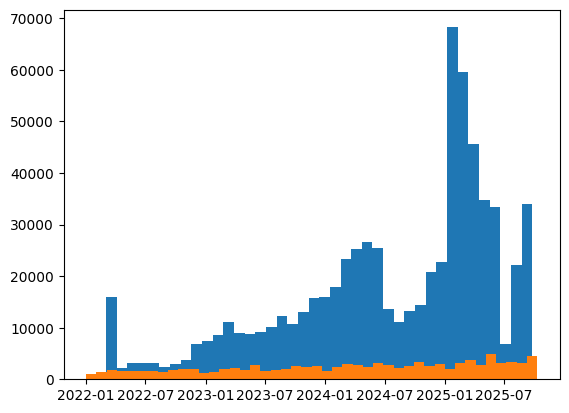

In [26]:
plt.hist(hf["createdAt"], bins=3*12+4)
plt.hist(arx[arx["submission_date"].dt.year>2021]["submission_date"], bins=3*12+8)
plt.show()

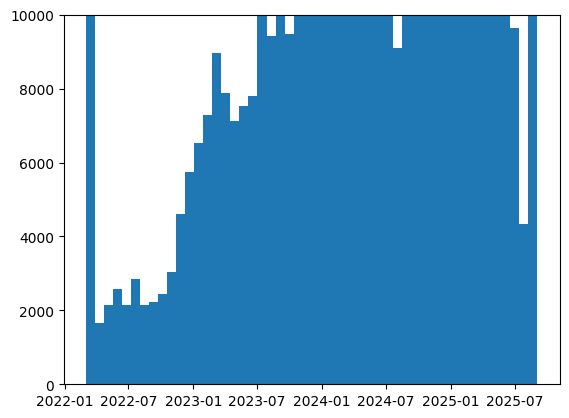

In [17]:
plt.hist(hf["createdAt"], bins=50)
plt.ylim(0, 10000)
plt.show()

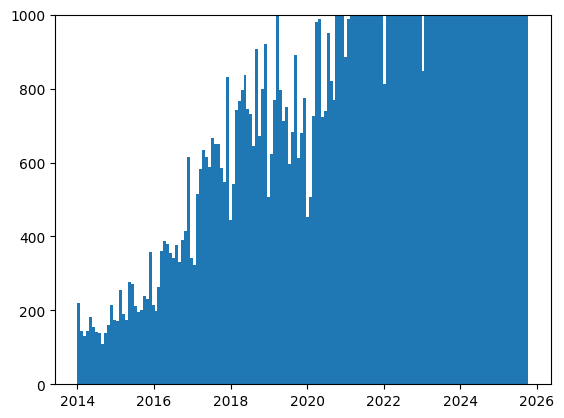

In [4]:
#plt.hist(arx["submission_date"], bins=(2024-1992)*12)
plt.hist(arx[arx["submission_date"].dt.year>2013]["submission_date"], bins=12*12+8)

plt.ylim(0, 1000)
plt.show()

In [15]:
arx

,title,categories,abstract,submission_date,authors_parsed,bin
id,,,,,,
1301.0048,Generating High-Order Threshold Functions with...,cs.NE,"In this paper, we consider situations in whi...",2013-01-01 02:20:31,"[['Kamada', 'Yukihiro', ''], ['Miyasaki', 'Kiy...",2013.01
1301.0127,A Semi-automated Statistical Algorithm for Obj...,cs.CV,We explicate a semi-automated statistical al...,2013-01-01 19:51:28,"[['Srivastava', 'Madhur', ''], ['Singh', 'Sati...",2013.01
1301.0167,Classifier Fusion Method to Recognize Handwrit...,cs.CV,Optical Character Recognition (OCR) is one o...,2013-01-02 04:45:44,"[['Mamatha', 'H. R.', ''], ['Karthik', 'S.', '...",2013.01
1301.0179,A Novel Design Specification Distance(DSD) Bas...,cs.LG,Organizing data into semantically more meani...,2013-01-02 07:13:19,"[['Doreswamy', '', ''], ['Hemanth', 'K. S.', '']]",2013.01
1301.0216,Applying Strategic Multiagent Planning to Real...,cs.AI,"Travel sharing, i.e., the problem of finding...",2013-01-02 12:06:59,"[['Hrnčíř', 'Jan', ''], ['Rovatsos', 'Michael'...",2013.01
...,...,...,...,...,...,...
2510.08561,MultiCOIN: Multi-Modal COntrollable Video INbe...,cs.CV,Video inbetweening creates smooth and natural ...,2025-10-09 17:59:27,"[['Tanveer', 'Maham', ''], ['Zhou', 'Yang', ''...",2025.10
2510.08565,NaViL: Rethinking Scaling Properties of Native...,cs.CV,Compositional training has been the de-facto p...,2025-10-09 17:59:37,"[['Tian', 'Changyao', ''], ['Li', 'Hao', ''], ...",2025.10
2510.08566,D$^2$GS: Depth-and-Density Guided Gaussian Spl...,cs.CV,Recent advances in 3D Gaussian Splatting (3DGS...,2025-10-09 17:59:49,"[['Song', 'Meixi', ''], ['Lin', 'Xin', ''], ['...",2025.10


In [2]:
arx.groupby(["bin"]).count()

,title,categories,abstract,submission_date,authors_parsed
bin,,,,,
2013.01,244,244,244,244,244
2013.02,306,306,306,306,306
2013.03,547,547,547,547,547
2013.04,130,130,130,130,130
2013.05,100,100,100,100,100
...,...,...,...,...,...
2025.06,3422,3422,3422,3422,3422
2025.07,3074,3074,3074,3074,3074
2025.08,3486,3486,3486,3486,3486


In [20]:
#plt.hist(
dur = (hf["last_modified"]-hf["createdAt"])
dur.mean(), dur.max(), dur.median()

(Timedelta('15 days 05:11:04.190678'),
 Timedelta('1278 days 10:00:28'),
 Timedelta('0 days 00:17:40'))

# binned data
we divide the data into bins based on date. We want lots of bins for high granularity, but also need plenty of data in each bin for it to be useful. Also, very fine granularity is not nescessary since the dates do not represent trend time that exactly (eg arxiv papers are developed ofer months then published).
Therefore, bins are based on month.

In [8]:
import dataset_loader

In [9]:
arx = dataset_loader._load_arxiv_timeline()
hf = dataset_loader._load_hf_timeline()

In [10]:
def group_dfs_in_months(m = 3): #m= number of months to combine in a bin (e.g. m=3 means we look at quarters)
    arx.loc[:,"bin"] = ((arx["submission_date"].dt.month+m-1)//m)/100 + arx["submission_date"].dt.year
    hf.loc[:,"bin"] = ((hf["createdAt"].dt.month+m-1)//m)/100 + hf["createdAt"].dt.year


In [11]:
def find_longest_true_sebseq(series, debug = False):
    # find longest consecutive subsequence of True

    # count position in subseq
    s2 = series.copy()
    s2 = s2.astype(int)
    count=0
    for id in series.index:
        if series.loc[id]:
            count +=1
        else:
            count = 0
        s2.loc[id] = count

    if debug:
        return s2
    series = series.iloc[:s2.argmax()+1] # remove part after the longest subseq
    series = series.iloc[-series[::-1].argmin():] # remove part before
    assert all(series)

    return series

def find_commonly_plentiful_subseries(threshold = 2000):

    arxiv_plentiful_months = arx.groupby(["bin"]).count()["title"] >= threshold
    hf_plentiful_months = hf.groupby(["bin"]).count()["modelId"] >= threshold

    both_plentify_months = arxiv_plentiful_months & hf_plentiful_months

    start = both_plentify_months[both_plentify_months==True].index.min()
    end = both_plentify_months[both_plentify_months==True].index.max()

    period = both_plentify_months.loc[start:end]

    return period



In [12]:

for m in [1,2,3,4]:
    group_dfs_in_months(m)
    print("m=", m)
    maxsums = [0]
    best_threshs = [0]
    prevl=0
    for threshold in range(1100, 10000, 100):
        period = find_commonly_plentiful_subseries(threshold)
        if len(period)==0:
            break
        series = find_longest_true_sebseq(period)
        l=len(series)
        sum_ = l*threshold
        if sum_>maxsums[-1]:
            maxsums.append(sum_)
            best_threshs.append(threshold)
            if l != prevl:
                print(prevl, maxsums[-2], best_threshs[-2])
            prevl = l
    print(prevl, maxsums[-1], best_threshs[-1])



m= 1
0 0 0
43 47300 1100
32 48000 1500
31 49600 1600
m= 2
0 0 0
22 57200 2600
16 57600 3600
m= 3
0 0 0
15 60000 4000
14 63000 4500
m= 4
0 0 0
12 61200 5100
11 61600 5600


In [14]:
# to find exact numbers
import pandas as pd
group_dfs_in_months(1)
pd.concat([arx.groupby(["bin"]).count()["title"], hf.groupby(["bin"]).count()["modelId"]], axis=1).min(axis=1, skipna=False)


bin
1993.08       NaN
1993.09       NaN
1993.11       NaN
1993.12       NaN
1994.01       NaN
            ...  
2025.06    3422.0
2025.07    1835.0
2025.08    3486.0
2025.09    3958.0
2025.10       NaN
Length: 370, dtype: float64

In [46]:
for threshold in [1103, 1517]: # these are the exact numbers in the months with fewest arxiv papers.
    period = find_commonly_plentiful_subseries(threshold)
    series = find_longest_true_sebseq(period)
    l=len(series)
    sum_ = l*threshold
    print(l, sum_, threshold)

43 47429 1103
29 43993 1517


Choosing m=1 for granularity since its not that much less than m=2 and m=3. Also choosing threshold of 1103, since it covers a lot longer period than 1517 and only slightly fewer examples.

In [ ]:
threshold = 1103
period = find_commonly_plentiful_subseries(threshold)
bin_range = period.index.min(), period.index.max()

In [ ]:
arx = arx[arx["bin"]>=bin_range[0]][arx["bin"]<=bin_range[1]]
hf = hf[hf["bin"]>=bin_range[0]][hf["bin"]<=bin_range[1]]

In [ ]:
#= arx.groupby(["bin"]).count()["title"]
hf = hf.groupby(["bin"]).sample(n=1103, random_state = 123)

In [ ]:
arx = arx.groupby(["bin"]).sample(n=1103, random_state = 123)

In [17]:

#arx.groupby(["bin"]).count()["title"]
hf.groupby(["bin"]).count()["modelId"]

bin
2022.03    15755
2022.04     1819
2022.05     2827
2022.06     2581
2022.07     3389
2022.08     2486
2022.09     2655
2022.10     3116
2022.11     4044
2022.12     6755
2023.01     7614
2023.02     8135
2023.03    10270
2023.04     8031
2023.05     8305
2023.06     8447
2023.07     9439
2023.08    10243
2023.09    11536
2023.10    11683
2023.11    12942
2023.12    15539
2024.01    16824
2024.02    16966
2024.03    22323
2024.04    24746
2024.05    25739
2024.06    20973
2024.07    12842
2024.08    10416
2024.09    12275
2024.10    13374
2024.11    18717
2024.12    22005
2025.01    56438
2025.02    54298
2025.03    50839
2025.04    32200
2025.05    30892
2025.06    27116
2025.07     1835
2025.08    30907
2025.09    24413
Name: modelId, dtype: int64

In [ ]:
hf

,modelId,createdAt,last_modified,bin
0,dp1812/celestial-mistral-7b-comprehensive,2025-08-28 19:37:18,2025-09-02 03:09:59,2025.08
1,mooperyou/blockassist-bc-beaked_frisky_ox_1756...,2025-09-02 03:09:12,2025-09-02 03:09:47,2025.09
2,rafitesnet00/blockassist-bc-scruffy_mighty_was...,2025-09-02 02:52:45,2025-09-02 02:56:48,2025.09
3,omerbektass/blockassist-bc-insectivorous_bold_...,2025-09-02 02:30:52,2025-09-02 02:30:55,2025.09
4,pictgensupport/Dragon3_733,2025-09-02 02:29:53,2025-09-02 02:29:56,2025.09
...,...,...,...,...
910717,sgonzalezygil/sd-finetuning-dreambooth-v5-500,2025-06-17 21:58:31,2025-06-17 22:01:12,2025.06
910718,Davidozito/fewshot-250-samples,2025-06-17 13:01:41,2025-06-17 14:16:59,2025.06
910719,milpu02/kutibuemix-xl,2025-06-17 11:07:01,2025-06-17 11:07:13,2025.06
910720,ReallyFloppyPenguin/Jan-nano-GGUF,2025-06-16 15:59:22,2025-06-16 16:08:29,2025.06


In [ ]:
hf.groupby(["bin"]).sample(n=1103, random_state = 123)

,modelId,createdAt,last_modified,bin
883573,allenai/unifiedqa-v2-t5-base-1363200,2022-03-02 23:29:05,2023-01-24 16:28:24,2022.03
619409,Helsinki-NLP/opus-mt-it-bg,2022-03-02 23:29:04,2023-08-16 11:58:46,2022.03
158464,wietsedv/wav2vec2-large-xlsr-53-dutch,2022-03-02 23:29:05,2023-09-11 08:54:57,2022.03
905004,huggingtweets/shishibane,2022-03-02 23:29:05,2021-06-23 18:24:55,2022.03
450388,hfl/chinese-legal-electra-small-discriminator,2022-03-02 23:29:05,2021-01-22 05:19:55,2022.03
...,...,...,...,...
907016,kunalsbhat/contractiq-gnx-20b-multidataset,2025-09-02 02:51:38,2025-09-02 02:51:40,2025.09
247,TheHuy/gpt-neo-1.3B-vietnamese,2025-09-01 15:32:36,2025-09-01 15:37:22,2025.09
907659,Muapi/zavy-s-cyberpunk-city-flux,2025-09-01 21:42:41,2025-09-01 21:43:20,2025.09
450602,acidjp/blockassist-bc-pesty_extinct_prawn_1756...,2025-09-02 05:46:46,2025-09-02 05:46:50,2025.09


In [ ]:
hf.groupby(["bin"]).sample(n=1, random_state = 123)

,modelId,createdAt,last_modified,bin
883573,allenai/unifiedqa-v2-t5-base-1363200,2022-03-02 23:29:05,2023-01-24 16:28:24,2022.03
900471,nntadotzip/bert-base-cased-IUChatbot-ontologyD...,2022-04-12 07:53:07,2022-04-12 08:14:00,2022.04
443610,TweebankNLP/bertweet-tb2_ewt-pos-tagging,2022-05-03 16:15:03,2022-05-05 00:23:51,2022.05
441421,nawta/wav2vec2-base-timit-demo-colab,2022-06-27 16:04:16,2022-06-28 12:47:04,2022.06
895793,chiendvhust/distilbert-base-uncased-finetuned-...,2022-07-06 09:44:38,2022-08-03 05:02:50,2022.07
439134,DOOGLAK/Tagged_Uni_100v0_NER_Model_3Epochs_AUG...,2022-08-11 17:53:19,2022-08-11 17:58:39,2022.08
893611,sd-concepts-library/guttestreker,2022-09-24 04:19:26,2022-09-24 04:19:49,2022.09
891812,reza-aditya/distilroberta-base-sentence-transf...,2022-10-25 00:36:01,2022-10-25 03:01:56,2022.10
891023,jjjj-j/distilbert-base-uncasedreference-finetu...,2022-11-11 14:06:04,2022-11-11 14:42:32,2022.11
886941,salehi/salehi_unit1,2022-12-26 10:20:25,2022-12-26 10:20:46,2022.12


In [ ]:
all(hf.groupby(["bin"]).count()["modelId"]==1103)

True

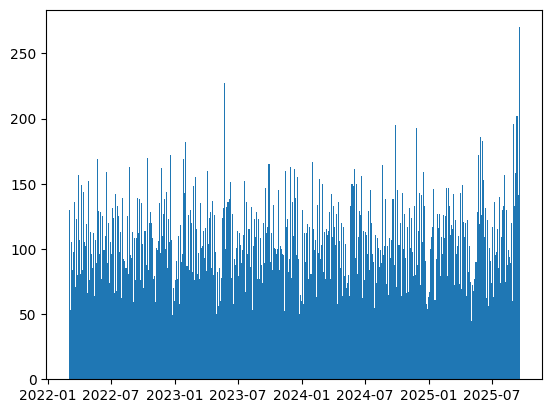

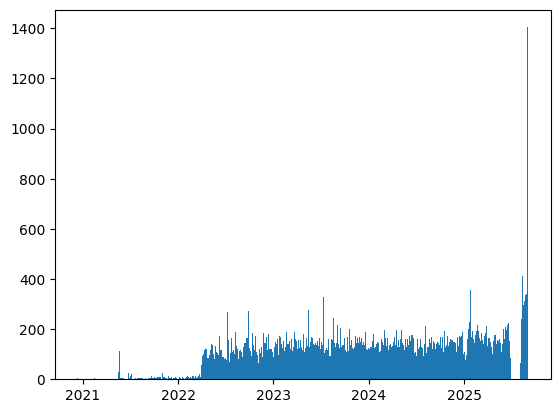

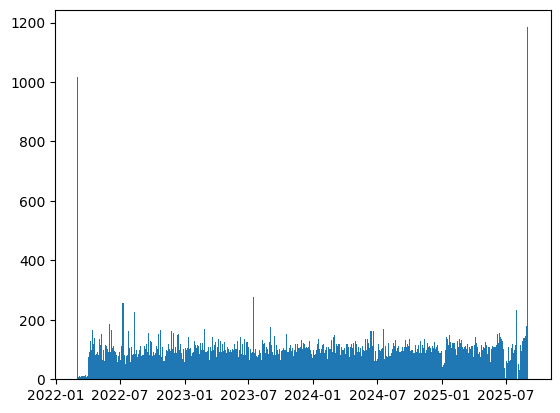

In [ ]:
import matplotlib.pyplot as plt
plt.hist(arx["submission_date"], bins=440)
plt.show()
plt.hist(hf["last_modified"], bins=440)
plt.show()
plt.hist(hf["createdAt"], bins=440)
plt.show()

/home/sondre/miniconda3/envs/deepseek_llmdap_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 974912/974912 [00:16<00:00, 57703.90 examples/s] 


Saving the dataset (8/8 shards): 100%|██████████| 974912/974912 [00:04<00:00, 229680.95 examples/s]
